In [2]:
# Load Comments
import pandas as pd
comments = pd.read_csv(r'\data\comments.csv')
comments.head()

,media_id,assigned_niche,account_handle,timestamp,caption,comment_user,comment_text
0,0,Home Design,chrislovesjulia,2026-05-26T18:39:17+0000,My hot take: turquoise pools should be saved f...,guanaha_tabeyes,"Because bright turquoise is a happy, it’s a Fl..."
1,0,Home Design,chrislovesjulia,2026-05-26T18:39:17+0000,My hot take: turquoise pools should be saved f...,farrellclick,Savannah has gross muddy ocean water and we ar...
2,0,Home Design,chrislovesjulia,2026-05-26T18:39:17+0000,My hot take: turquoise pools should be saved f...,huntfish70,White. Water is clear in the shallow end and f...
3,0,Home Design,chrislovesjulia,2026-05-26T18:39:17+0000,My hot take: turquoise pools should be saved f...,theboardman247,What is the pool color?
4,0,Home Design,chrislovesjulia,2026-05-26T18:39:17+0000,My hot take: turquoise pools should be saved f...,rajkamal_tarar,"Can""you""share @carolina__diaries"


## Top keywords

### Frequency-based approach

Simply removing NLTK stopwords and sorting the rest by number of appearances in comments.

In [3]:
# Remove NLTK stopwords
from collections import Counter
from nltk.corpus import stopwords
import nltk
import re

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

words = []

for comment in comments.comment_text.dropna():
    tokens = re.findall(r"\b[a-z]+\b", comment.lower())
    words.extend([w for w in tokens if w not in stop_words])

top_words = Counter(words).most_common(20)

words = [word for word, _ in top_words]
counts = [count for _, count in top_words]

results = pd.DataFrame({'word': words, 'count': counts})
results.sort_values(by='count', ascending=False)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,word,count
0,link,2168
1,love,1686
2,toys,1597
3,outdoor,1215
4,window,1111
5,drop,969
6,lawsuit,967
7,like,898
8,storage,717
9,program,705


### TF-IDF
Performed TF-IDF (Term Frequency-Inverse Document Frequency) analysis to identify the most "important" words in the comments.

In [4]:
#TfidVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=1000
)

X = vectorizer.fit_transform(comments.comment_text.dropna())

scores = X.sum(axis=0).A1
terms = vectorizer.get_feature_names_out()

top_keywords = (
    pd.DataFrame({"term": terms, "score": scores})
      .sort_values("score", ascending=False)
      .head(20)
)

print(top_keywords)

          term        score
493       link  2085.260389
888       toys  1589.751196
612    outdoor  1190.274947
960     window  1093.565240
515       love   799.591614
828    storage   713.477040
685    program   687.341648
66   beautiful   407.593380
242       drop   398.936911
471    lawsuit   395.124947
36     amazing   372.288477
982        wow   311.823229
450       just   287.899410
491       like   285.907740
359      great   229.734229
349       good   227.150072
557        mom   219.243439
375      happy   214.956360
991        yes   209.386969
581       need   195.269806


### Breakdown top keywords for specific account name

In [5]:
comments.account_handle.unique()

array(['chrislovesjulia', 'amberinteriors', 'thecontainerstore',
       'petermckinnon', 'brandonwoelfel', 'jimmychin', 'chrisburkard',
       'theroyalportfolio', 'busytoddler', 'biglittlefeelings',
       'takingcarababies', 'mothercould', 'adamgrant', 'melrobbins',
       'ted', 'khanacademy', 'charitywater', 'tnkidsbelong',
       'bittyandbeauscoffee', 'feedingamerica', 'beautifuldestinations',
       'earthpix', 'taramilktea', 'lonelyplanet', 'rei', 'natgeo',
       'trail.magik', 'patagonia', 'minimalistbaker', 'fitwaffle',
       'wishbonekitchen', 'rainbowplantlife', 'melissawoodhealth',
       'yoga_girl', 'headspace', 'marieforleo', 'simonsinek', 'aliabdaal',
       'latermedia', 'hootsuite', 'herfirst100k', 'thefinancialdiet',
       'ramit', 'your.richbff', 'kayla_itsines', 'onepeloton',
       'smithsonian', 'spacescience', 'natgeolearning', 'thedodo',
       'oceanconservancy', 'adobecreativecloud', 'canva', 'behance',
       'goodreads', 'penguinrandomhouse', 'github', 

In [6]:
# NLTK stopwords
from collections import Counter
from nltk.corpus import stopwords
import nltk
import re

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def find_top_words(df, account_handle=None, num_words=None):

  words = []
  # select account handle
  if account_handle is None:
    comments = df
  else:
    comments = df[df.account_handle == account_handle]
  # print total comments and total videos
  total_comments = comments.shape[0]
  total_videos = comments.media_id.nunique()

  print(f'Total comments: {total_comments}')
  print(f'Total videos: {total_videos}')
  # find top words
  for comment in comments.comment_text.str.lower():
      tokens = re.findall(r"\b[a-z]+\b", comment)
      words.extend([w for w in tokens if w not in stop_words])
  # select top words
  if num_words is None:
    top_words = Counter(words).most_common()
  else:
    top_words = Counter(words).most_common(num_words)
  # find words, comment count, video count
  words = [word for word, _ in top_words]
  counts = [count for _, count in top_words]
  video_counts = [comments[comments.comment_text.str.contains(word)].media_id.nunique() for word in words]

  results = pd.DataFrame({'word': words, 'comment_count': counts, 'video_count': video_counts}).sort_values(by='comment_count', ascending=False)
  return results


find_top_words(comments, account_handle='chrislovesjulia', num_words=20)

Total comments: 5425
Total videos: 27


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,word,comment_count,video_count
0,link,2131,14
1,window,1099,5
2,pool,273,6
3,please,244,19
4,love,229,16
5,like,131,12
6,would,110,12
7,color,88,11
8,links,80,8
9,get,77,16


In [7]:
# Associated words
def find_associated_words(df, word, account_handle=None, num_words=None):
  df = df[df.comment_text.notnull()]
  filtered_df = df[df.comment_text.str.contains(word)]
  if account_handle is None:
    comments = filtered_df
  else:
    comments = filtered_df[filtered_df.account_handle == account_handle]
  result = find_top_words(comments, account_handle=account_handle, num_words=num_words)
  return result

find_associated_words(comments, word='love', account_handle='chrislovesjulia', num_words=20)

Total comments: 181
Total videos: 16


,word,comment_count,video_count
0,love,155,16
1,pool,52,4
2,would,44,6
3,chrislovesjulia,19,11
4,home,12,5
5,color,11,2
6,lovely,11,6
7,details,10,2
8,dark,10,2
9,cover,9,3


## Sentiment analysis

### Keyword (From Jerry)

In [8]:
import re
comment_df = comments.copy()

# Convert comments to lowercase for easier keyword matching
def clean_text(text):
    text = str(text).lower()

    # remove leading numbering like "1."
    text = re.sub(r"^\s*\d+\.\s*", "", text)

    # remove username prefixes like "username:"
    text = re.sub(r"^[a-z0-9_.]+:\s*", "", text)

    # normalize apostrophes
    text = text.replace("", "'").replace("’", "'")

    # remove urls and mentions
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@[A-Za-z0-9_]+", "", text)

    # remove hashtag symbol but keep word
    text = re.sub(r"#", "", text)

    # keep words and ? !
    text = re.sub(r"[^\w\s\?\!']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

comment_df["comment_clean"] = comment_df["comment_text"].apply(clean_text)

# Define keywords for positive reactions
comment_df["positive_jerry"] = comment_df["comment_clean"].str.contains(
    r"\b(?:love|amazing|great|awesome|beautiful|helpful|perfect|incredible)\b",
    regex=True, na=False
)

In [9]:
comment_df["positive_jerry"].mean()

np.float64(0.10961896047932469)

In [10]:
comment_df.groupby('account_handle').agg(
    positive_rate_jerry=('positive_jerry', 'mean'),
    num_comments=('comment_text', 'count')
    )

,positive_rate_jerry,num_comments
account_handle,,
adamgrant,0.102564,507
adobe,0.153846,52
adobecreativecloud,0.111111,18
aliabdaal,0.026415,265
amberinteriors,0.303906,1280
...,...,...
trail.magik,0.000000,2
victoriassecret,0.046154,650
wishbonekitchen,0.062500,304


### NLTK

In [11]:
!pip install nltk

In [12]:
import nltk
nltk.download('vader_lexicon')

from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

def sent_analysis_nltk(comment):
    scores = sia.polarity_scores(comment)
    compound = scores['compound']

    # Save the raw score
    category = None
    if compound >= 0.25:
        category = "positive"
    elif compound <= -0.25:
        category = "negative"
    else:
        category = "neutral"

    return compound, category

# Apply function
comment_df[['nltk_score', 'nltk_sentiment']] = comment_df['comment_clean'].apply(
    lambda x: pd.Series(sent_analysis_nltk(x))
)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [13]:
comment_df['positive_nltk'] = comment_df['nltk_sentiment'] == 'positive'
comment_df['positive_nltk'].mean()

np.float64(0.2990466633216257)

In [14]:
comment_df['nltk_sentiment'].value_counts()/len(comment_df)

,count
nltk_sentiment,
neutral,0.629497
positive,0.299047
negative,0.071456


In [15]:
import matplotlib.pyplot as plt
import numpy as np

def plot_sentiment_distribution(comment_df):
  # Create a figure with two subplots
  fig, axes = plt.subplots(1, 2, figsize=(16, 6))

  # --- Left Subplot: Pie Chart of NLTK Sentiment Distribution ---
  sentiment_counts = comment_df['nltk_sentiment'].value_counts(normalize=True)
  labels = sentiment_counts.index.tolist()

  # Define custom colors for sentiment categories
  colors = []
  for label in labels:
      if label == 'positive':
          colors.append('lightgreen')
      elif label == 'neutral':
          colors.append('lightyellow')
      elif label == 'negative':
          colors.append('lightcoral')

  # Plot pie chart with percentages
  wedges, texts, autotexts = axes[0].pie(sentiment_counts,
                                        autopct='%1.1f%%',
                                        colors=colors,
                                        startangle=90,
                                        wedgeprops=dict(width=0.3))
  axes[0].set_title('NLTK Sentiment Distribution')
  axes[0].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

  # Add legend
  legend = axes[0].legend(wedges, [f'{l} ({p:.1%})' for l, p in zip(labels, sentiment_counts)],
                title="Sentiment",
                loc="center left",
                bbox_to_anchor=(0.9, 0, 0.5, 1))

  # Add a box around the pie chart subplot
  axes[0].patch.set_edgecolor('black')
  axes[0].patch.set_linewidth(1.5)

  # Add a box around the legend
  legend.get_frame().set_edgecolor('black')
  legend.get_frame().set_linewidth(1.5)

  # --- Right Subplot: Histogram of NLTK Scores ---
  min_score = comment_df['nltk_score'].min()
  max_score = comment_df['nltk_score'].max()

  # Ensure bins are divisible by 0.25 and cover the range
  bins = np.arange(np.floor(min_score / 0.25) * 0.25, np.ceil(max_score / 0.25) * 0.25 + 0.25, 0.25)

  n, bins, patches = axes[1].hist(comment_df['nltk_score'].dropna(), bins=bins, edgecolor='black')

  # Color bars based on score ranges
  for i, patch in enumerate(patches):
      if bins[i+1] <= -0.25:
          patch.set_facecolor('lightcoral') # Red for negative
      elif bins[i] >= 0.25:
          patch.set_facecolor('lightgreen') # Green for positive
      else:
          patch.set_facecolor('lightyellow') # Yellow for neutral

  axes[1].set_title('NLTK Score Distribution')
  axes[1].set_xlabel('Sentiment Score')
  axes[1].set_ylabel('Number of Comments')

  # Add custom x-axis labels
  axes[1].text(0.95, -0.1, 'Positive', transform=axes[1].transAxes, ha='right')
  axes[1].text(0.05, -0.1, 'Negative', transform=axes[1].transAxes, ha='left')

  plt.tight_layout()
  plt.show()

In [16]:
accounts = comment_df.groupby('account_handle').agg(
    positive_rate_jerry=('positive_jerry', 'mean'),
    positive_rate_nltk=('positive_nltk', 'mean'),
    num_comments=('comment_text', 'count')
    )
accounts.sort_values(by='positive_rate_nltk', ascending=True)

,positive_rate_jerry,positive_rate_nltk,num_comments
account_handle,,,
idianamoldovan,0.000000,0.000000,7
trail.magik,0.000000,0.000000,2
spacescience,0.000000,0.000000,11
busytoddler,0.027488,0.071381,4511
aliabdaal,0.026415,0.079245,265
...,...,...,...
amberinteriors,0.303906,0.575781,1280
thefinancialdiet,0.166667,0.666667,12
fitwaffle,0.157895,0.684211,19


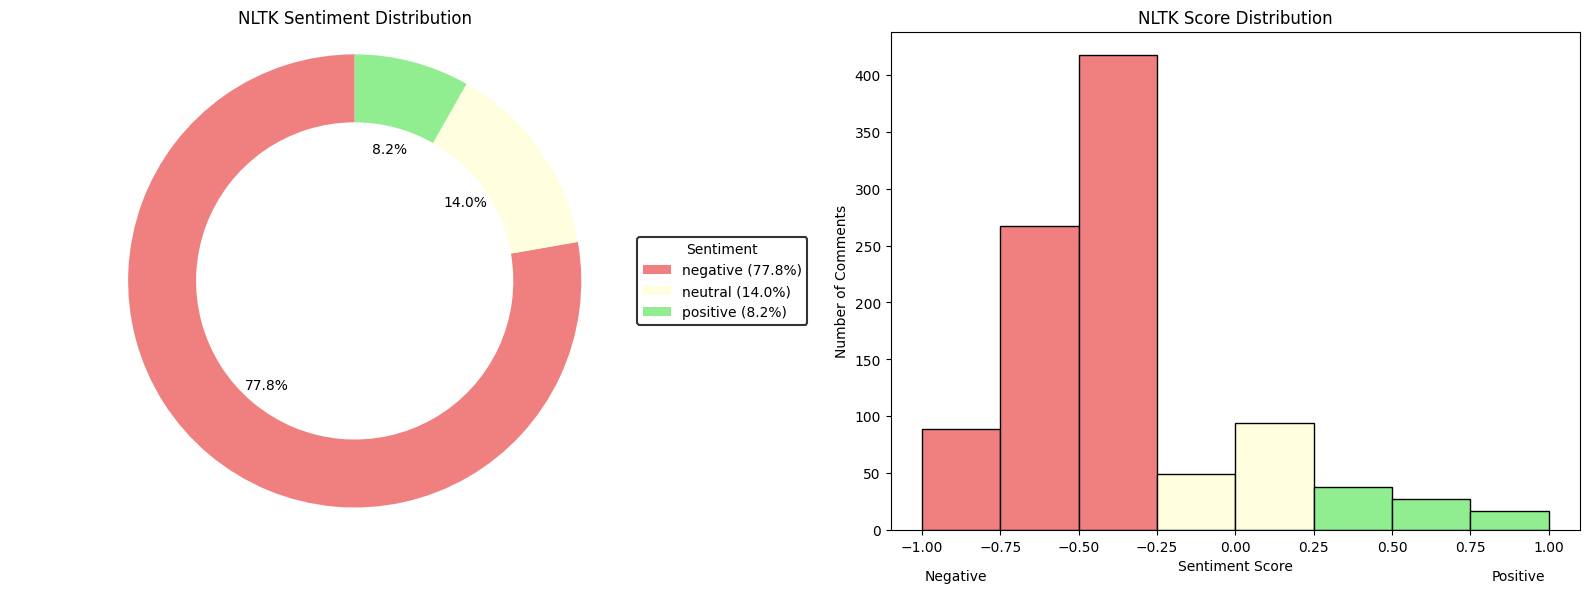

In [17]:
# What's going on in patagonia??
patagonia = comment_df[comment_df['account_handle']=='patagonia']
plot_sentiment_distribution(patagonia)

In [18]:
# Check out some comments
comment_df[comment_df["account_handle"]=='penguinrandomhouse'].sample(50)

,media_id,assigned_niche,account_handle,timestamp,caption,comment_user,comment_text,comment_clean,positive_jerry,nltk_score,nltk_sentiment,positive_nltk
31999,432,Books,penguinrandomhouse,2026-05-20T17:24:21+0000,Graphic novels allow the reluctant reader to s...,siskikallaillustration,Love graphic novels as do my kids. I always wo...,love graphic novels as do my kids i always won...,True,0.6752,positive,True
32131,434,Books,penguinrandomhouse,2026-05-15T16:53:41+0000,?? how fast of a reader are you??? ????,ginny3w,"Cancer here, and not close at all. ??",cancer here and not close at all ??,False,-0.6966,negative,False
32248,435,Books,penguinrandomhouse,2026-05-13T17:51:36+0000,time to hit your (reading) goals ?? do you fol...,meena.reads.books,??yesss - sharing the information we need,??yesss sharing the information we need,False,0.4871,positive,True
31981,432,Books,penguinrandomhouse,2026-05-20T17:24:21+0000,Graphic novels allow the reluctant reader to s...,theliteracy_nook,??????we agree!!,??????we agree!!,False,0.6179,positive,True
32139,434,Books,penguinrandomhouse,2026-05-15T16:53:41+0000,?? how fast of a reader are you??? ????,themillennialdiaries,"As a hyperlexic libra, how dare you",as a hyperlexic libra how dare you,False,0.0000,neutral,False
32221,435,Books,penguinrandomhouse,2026-05-13T17:51:36+0000,time to hit your (reading) goals ?? do you fol...,ckmead79,???? love it!!,???? love it!!,True,0.7746,positive,True
32125,434,Books,penguinrandomhouse,2026-05-15T16:53:41+0000,?? how fast of a reader are you??? ????,what.abi.readsss,Not Taurus me laughing in the corner ????,not taurus me laughing in the corner ????,False,-0.5556,negative,False
32033,432,Books,penguinrandomhouse,2026-05-20T17:24:21+0000,Graphic novels allow the reluctant reader to s...,laumoraiti,"As an illustrator, making early reader graphic...",as an illustrator making early reader graphic ...,False,0.7998,positive,True
31980,432,Books,penguinrandomhouse,2026-05-20T17:24:21+0000,Graphic novels allow the reluctant reader to s...,the_kinley_kollection,"Literary access is more than books on a shelf,...",literary access is more than books on a shelf ...,False,0.8844,positive,True
32097,434,Books,penguinrandomhouse,2026-05-15T16:53:41+0000,?? how fast of a reader are you??? ????,mohsinsdigidiary,"Yep, a week sounds about right lol",yep a week sounds about right lol,False,0.6124,positive,True


## Emotion Categorization

In the below cells, I'll analyze the emotions in the comments beyond positive, negative, and neutral.

### NRCLEX (7 emotions)

In [19]:
!pip install nrclex

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.3 MB/s eta 0:00:00


In [20]:
!python -m textblob.download_corpora

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.


In [21]:
from nrclex import NRCLex

text = "I love your product, but I'm so upset you chose this route as a human."
emotion = NRCLex()
emotion.load_raw_text(text)

In [22]:
emotion.raw_emotion_scores

{'joy': 1, 'positive': 1, 'anger': 1, 'negative': 1, 'sadness': 1}

In [23]:
from nrclex import NRCLex
import pandas as pd

def emotion_classification(text):
  # Handle non-string inputs gracefully
  if not isinstance(text, str):
    return {}
  emotion = NRCLex()
  emotion.load_raw_text(text)
  return emotion.raw_emotion_scores

# Apply the emotion classification function to the 'comment_clean' column
# This will result in a Series where each element is a dictionary of emotion scores
emotion_scores_series = comment_df['comment_clean'].apply(emotion_classification)

# Convert the Series of dictionaries into a DataFrame
# Each key (emotion name) from the dictionaries will become a column in this new DataFrame
emotions_df_nrclex = pd.DataFrame(list(emotion_scores_series)).fillna(0)

# Concatenate the new emotions_df with the original comment_df
# This will add new columns for each emotion (e.g., 'joy', 'anger', 'sadness', etc.).
# Use .fillna(0) to replace any NaN values (for emotions not detected in a comment) with 0.

In [24]:
emotions_df_nrclex.head()

,anticipation,joy,positive,trust,disgust,negative,sadness,anger,fear,surprise
0,2.0,2.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0
2,2.0,3.0,3.0,2.0,0.0,1.0,1.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
emotions_df_nrclex.to_csv('emotions_df_nrclex.csv')

### GoEmotions

https://research.google/blog/goemotions-a-dataset-for-fine-grained-emotion-classification/

In [26]:
!pip install transformers sentencepiece accelerate

In [28]:
from transformers import pipeline
import pandas as pd
import numpy as np

# -----------------------------
# 1. Load the GoEmotions model
# -----------------------------
classifier = pipeline(
    "text-classification",
    model="SamLowe/roberta-base-go_emotions",
    top_k=None,
    device=0,
    truncation=True,
    max_length=512
)

# -----------------------------
# 2. Prepare batch inference
# -----------------------------
batch_size = 32
all_outputs = []

comments = comment_df["comment_clean"].fillna("").astype(str).tolist()

for i in range(0, len(comments), batch_size):
    batch = comments[i:i+batch_size]
    outputs = classifier(batch)   # list of lists of dicts
    all_outputs.extend(outputs)

# -----------------------------
# 3. Convert model output → DataFrame
# -----------------------------
# Get the full emotion label set from the model
all_labels = sorted({item['label'] for sublist in all_outputs for item in sublist})

# Create an empty matrix
scores_matrix = np.zeros((len(all_outputs), len(all_labels)))

label_to_idx = {label: idx for idx, label in enumerate(all_labels)}

# Fill the matrix
for row_idx, emotion_list in enumerate(all_outputs):
    for item in emotion_list:
        col_idx = label_to_idx[item['label']]
        scores_matrix[row_idx, col_idx] = item['score']

# Build the final DataFrame
emotions_go_df = pd.DataFrame(scores_matrix, columns=all_labels)

# Optional: attach back to original dataframe
full = pd.concat([comment_df.reset_index(drop=True), emotions_go_df], axis=1)

emotions_go_df.head()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,...,love,nervousness,neutral,optimism,pride,realization,relief,remorse,sadness,surprise
0,0.687320,0.614180,0.001928,0.004632,0.029246,0.002798,0.003809,0.004812,0.002291,0.002195,...,0.048622,0.000818,0.008484,0.005144,0.003892,0.008333,0.003634,0.000612,0.002442,0.003108
1,0.004509,0.004671,0.005456,0.021131,0.006821,0.004186,0.088151,0.855117,0.004348,0.011005,...,0.003089,0.001906,0.130976,0.003842,0.000081,0.003571,0.000301,0.001920,0.005325,0.007012
2,0.007427,0.001298,0.000497,0.002623,0.224314,0.001267,0.015855,0.001840,0.000845,0.002245,...,0.001734,0.000668,0.629079,0.005840,0.000504,0.078464,0.001037,0.000447,0.001758,0.000818
3,0.001914,0.001785,0.001932,0.006794,0.005953,0.001376,0.244305,0.603850,0.001070,0.001696,...,0.001823,0.000377,0.356514,0.002119,0.000044,0.003496,0.000124,0.000452,0.001063,0.004686
4,0.001995,0.002152,0.002328,0.006544,0.011959,0.005260,0.040229,0.389766,0.020318,0.001546,...,0.004867,0.000376,0.700152,0.004992,0.000088,0.002550,0.000208,0.000627,0.001454,0.001454


In [29]:
emotions_go_df.columns

Index(['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
       'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
       'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
       'joy', 'love', 'nervousness', 'neutral', 'optimism', 'pride',
       'realization', 'relief', 'remorse', 'sadness', 'surprise'],
      dtype='object')

7. Top 15 Emotion Distribution:
                       Count
neutral         20044.423074
admiration       3772.057260
curiosity        3271.939687
confusion        1853.346799
love             1666.773099
approval         1368.037095
excitement        834.254425
surprise          695.666020
gratitude         693.610944
joy               560.249588
annoyance         532.665930
disapproval       426.722887
amusement         423.725114
realization       385.539957
optimism          329.304186
disappointment    292.914328
desire            279.745140
sadness           266.650463
anger             232.459354
caring            187.780087
disgust           128.027581
fear               93.237479
embarrassment      63.090441
remorse            54.444841
pride              40.043409
relief             38.976005
nervousness        36.805080
grief              22.525576


/tmp/ipykernel_1365/834309240.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y=emotion_df.index, data=emotion_df.head(29), palette='rainbow')


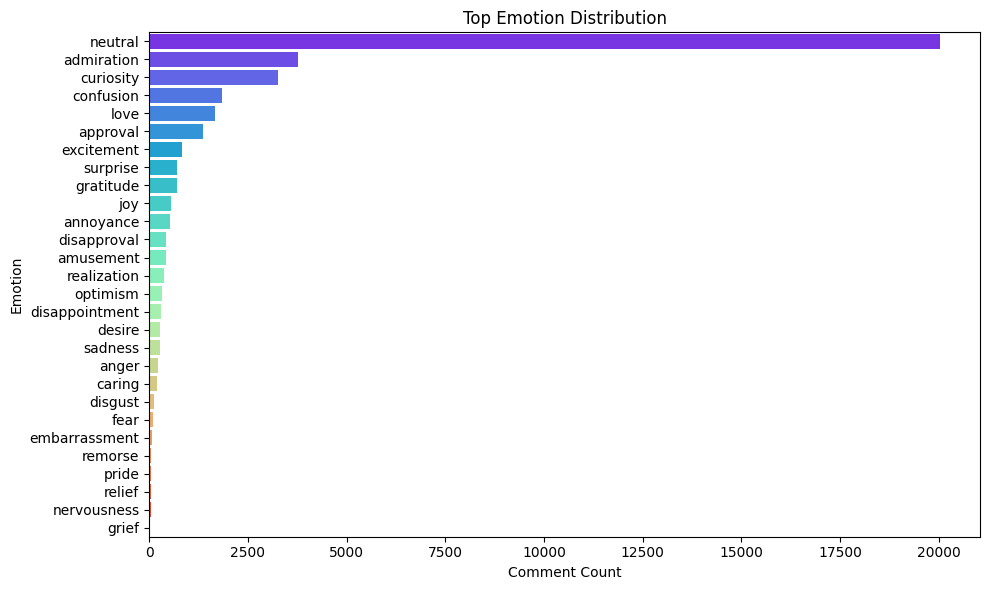

In [31]:
import seaborn as sns
# 7. Analyze Emotions with Seaborn plot
emotion_sums = emotions_go_df.sum()
emotion_df = emotion_sums.sort_values(ascending=False).to_frame("Count")
print("7. Top 15 Emotion Distribution:")
print(emotion_df.head(29))
if not emotion_df.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Count', y=emotion_df.index, data=emotion_df.head(29), palette='rainbow')
    plt.title(f'Top Emotion Distribution')
    plt.xlabel('Comment Count')
    plt.ylabel('Emotion')
    plt.tight_layout()
    plt.savefig(f'emotion_distribution.png')
    plt.show()
else:
    print("No emotion data to display.")